# Kidney Ultrasound Multiclass Segmentation

Pipeline per la segmentazione multiclasse di immagini ecografiche renali:
1. Dataset loading (immagini US + maschere multiclasse)
2. Preprocessing & Data Augmentation 
3. Segmentazione con Res-UNet multiclasse

**Classi di segmentazione:**
- 0: Background (nero)
- 1: Capsule (rosso scuro) - contorno esterno del rene
- 2: Central Echo Complex - CEC (blu) - zona centrale
- 3: Medulla (verde) - zona intermedia
- 4: Cortex (giallo/verde) - zona esterna interna

Riferimento per i dati: [KidneyUS GitHub](https://github.com/rsingla92/kidneyUS)

In [19]:
# Le dipendenze sono già installate nel venv
# !pip install -q scikit-image plotly nibabel opencv-python-headless

In [20]:
import os
import random
import numpy as np
import warnings
from tqdm import tqdm
from glob import glob
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

Device: mps


# 2. Configurazione Dataset e Iperparametri

In [21]:
# Dataset paths
BASE_DIR = Path("/Users/ada/Desktop/SegRENE")
DATA_DIR = BASE_DIR / "dataset_segmentation"

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"
OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

NUM_CLASSES = 5
CLASS_NAMES = ['Background', 'Capsule', 'CEC', 'Medulla', 'Cortex']
CLASS_COLORS = [
    (0, 0, 0),
    (180, 80, 80),
    (80, 80, 180),
    (80, 180, 80),
    (180, 180, 80),
]

CMAP = ListedColormap([tuple(c/255 for c in color) for color in CLASS_COLORS])

# Hyperparameters
IMG_SIZE = 256
BATCH_SIZE = 8
LR = 1e-3
N_EPOCHS = 50
PATIENCE = 15

# Class weights (inverse frequency)
CLASS_WEIGHTS = torch.tensor([0.1, 2.5, 4.0, 7.0, 12.0]).to(device)

print(f"Dataset: {DATA_DIR}")
print(f"Classes: {NUM_CLASSES} - {CLASS_NAMES}")

Dataset: /Users/ada/Desktop/SegRENE/dataset_segmentation
Classes: 5 - ['Background', 'Capsule', 'CEC', 'Medulla', 'Cortex']


In [22]:
def load_split_paths(split_dir):
    """Load image-mask pairs for a split."""
    images_dir = split_dir / "images"
    masks_dir = split_dir / "masks_class"
    
    image_paths = sorted(list(images_dir.glob("*.png")))
    
    pairs = []
    for img_path in image_paths:
        mask_path = masks_dir / img_path.name
        if mask_path.exists():
            pairs.append((img_path, mask_path))
    
    return pairs

train_pairs = load_split_paths(TRAIN_DIR)
val_pairs = load_split_paths(VAL_DIR)
test_pairs = load_split_paths(TEST_DIR)

print(f"Train: {len(train_pairs)}")
print(f"Val: {len(val_pairs)}")
print(f"Test: {len(test_pairs)}")

Train: 373
Val: 80
Test: 81


# 3. Visualizzazione Dataset Multiclasse

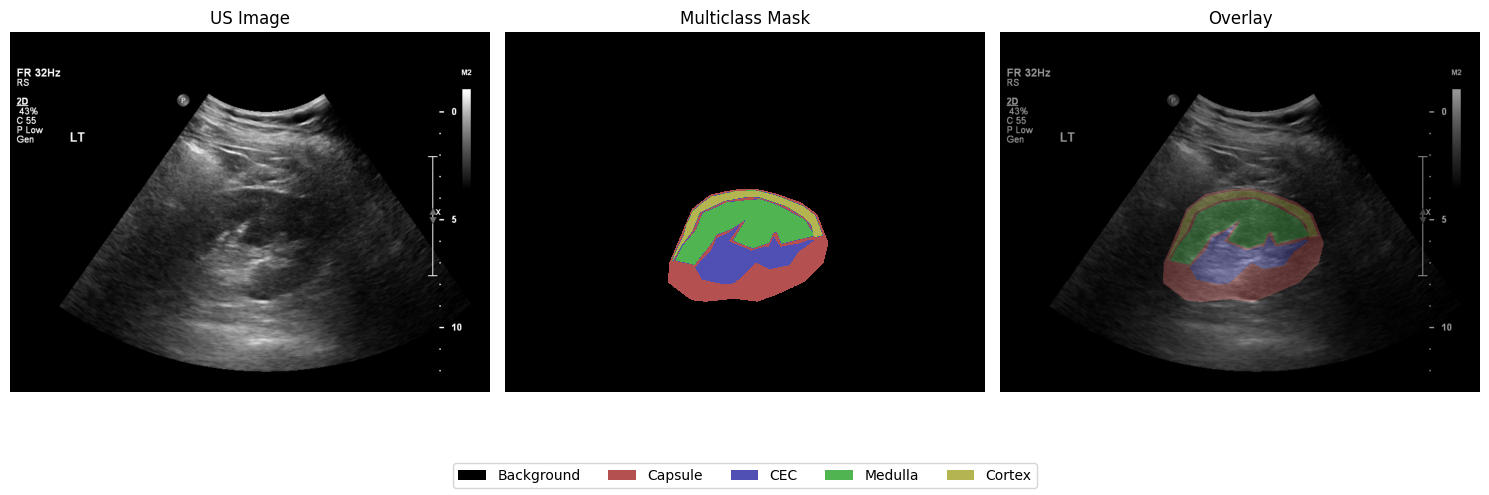

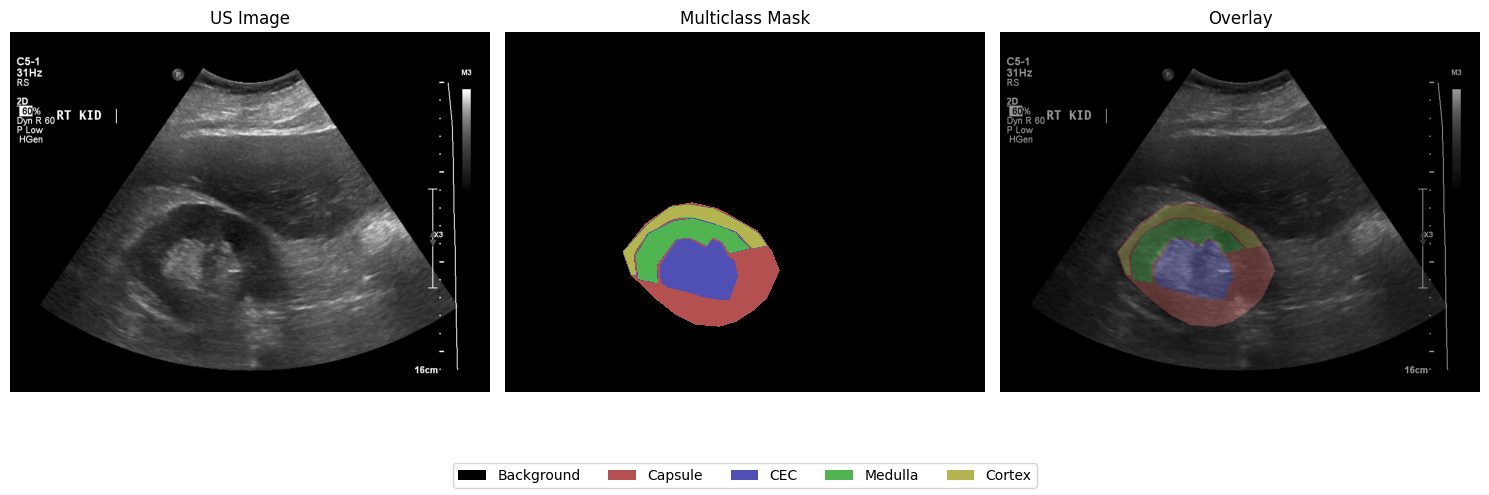

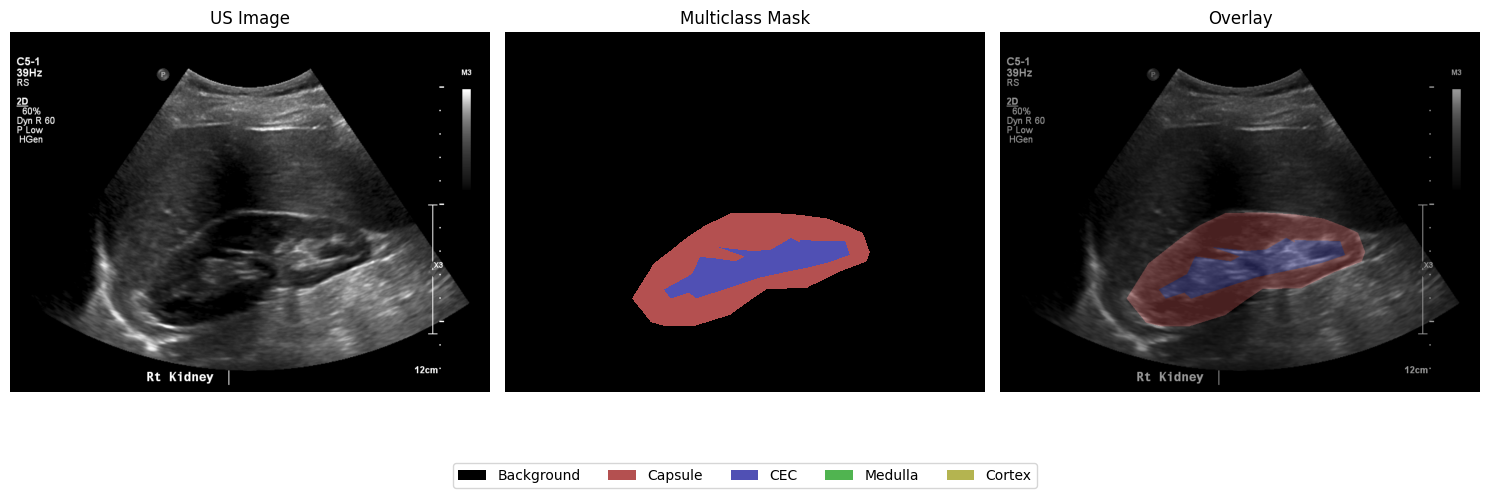

In [23]:
def visualize_multiclass_sample(img_path, mask_path):
    """Visualize US image with multiclass mask."""
    img = np.array(Image.open(img_path).convert('L'))
    mask = np.array(Image.open(mask_path))
    
    mask_rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for class_id, color in enumerate(CLASS_COLORS):
        mask_rgb[mask == class_id] = color
    
    img_rgb = np.stack([img, img, img], axis=-1)
    overlay = (0.6 * img_rgb + 0.4 * mask_rgb).astype(np.uint8)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title('US Image')
    axes[0].axis('off')
    
    axes[1].imshow(mask, cmap=CMAP, vmin=0, vmax=4)
    axes[1].set_title('Multiclass Mask')
    axes[1].axis('off')
    
    axes[2].imshow(overlay)
    axes[2].set_title('Overlay')
    axes[2].axis('off')
    
    patches = [plt.Rectangle((0,0), 1, 1, fc=tuple(c/255 for c in color)) 
               for color in CLASS_COLORS]
    fig.legend(patches, CLASS_NAMES, loc='lower center', ncol=5)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    plt.show()

for img_path, mask_path in random.sample(train_pairs, min(3, len(train_pairs))):
    visualize_multiclass_sample(img_path, mask_path)

# 4. Dataset e Data Augmentation Multiclasse

In [24]:
import torchvision.transforms.functional as TF
from scipy.ndimage import gaussian_filter, map_coordinates


def elastic_transform(image, mask, alpha=50, sigma=5):
    """Elastic deformation for anatomical variation simulation."""
    random_state = np.random.RandomState(None)
    shape = image.shape[:2]
    
    dx = gaussian_filter((random_state.rand(*shape) * 2 - 1), sigma) * alpha
    dy = gaussian_filter((random_state.rand(*shape) * 2 - 1), sigma) * alpha
    
    x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
    indices = (np.clip(y + dy, 0, shape[0]-1).astype(int),
               np.clip(x + dx, 0, shape[1]-1).astype(int))
    
    image_transformed = image[indices]
    mask_transformed = mask[indices]
    
    return image_transformed, mask_transformed


def cutout(image, mask, num_holes=1, max_h_size=40, max_w_size=40):
    """CutOut: removes random rectangular regions."""
    h, w = image.shape[:2]
    image_out = image.copy()
    
    for _ in range(num_holes):
        hole_h = random.randint(max_h_size // 2, max_h_size)
        hole_w = random.randint(max_w_size // 2, max_w_size)
        
        y = random.randint(0, h - hole_h)
        x = random.randint(0, w - hole_w)
        
        image_out[y:y+hole_h, x:x+hole_w] = 0
    
    return image_out, mask


def grid_distortion(image, mask, num_steps=5, distort_limit=0.3):
    """Grid-based distortion for local deformation simulation."""
    h, w = image.shape[:2]
    
    x_steps = np.linspace(0, w, num_steps)
    y_steps = np.linspace(0, h, num_steps)
    
    x_new = x_steps + np.random.uniform(-distort_limit, distort_limit, num_steps) * (w / num_steps)
    y_new = y_steps + np.random.uniform(-distort_limit, distort_limit, num_steps) * (h / num_steps)
    
    x_new = np.clip(x_new, 0, w-1)
    y_new = np.clip(y_new, 0, h-1)
    
    from scipy.interpolate import interp1d
    
    map_x = np.zeros((h, w), dtype=np.float32)
    map_y = np.zeros((h, w), dtype=np.float32)
    
    for i in range(h):
        map_x[i, :] = np.interp(np.arange(w), x_steps, x_new)
    for j in range(w):
        map_y[:, j] = np.interp(np.arange(h), y_steps, y_new)
    
    image_out = cv2.remap(image, map_x, map_y, cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)
    mask_out = cv2.remap(mask.astype(np.float32), map_x, map_y, cv2.INTER_NEAREST, borderMode=cv2.BORDER_REFLECT)
    
    return image_out, mask_out.astype(np.uint8)


class KidneyMulticlassDataset(Dataset):
    """Dataset for kidney multiclass segmentation with augmentation."""
    
    def __init__(self, pairs, img_size=256, augment=False, num_classes=5):
        self.pairs = pairs
        self.img_size = img_size
        self.augment = augment
        self.num_classes = num_classes

    def __len__(self):
        return len(self.pairs)

    def _add_gaussian_noise(self, img_tensor, std=0.05):
        noise = torch.randn_like(img_tensor) * std
        return torch.clamp(img_tensor + noise, 0, 1)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        
        img = np.array(Image.open(img_path).convert('L'))
        mask = np.array(Image.open(mask_path))
        
        img = cv2.resize(img, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)

        if self.augment:
            # Elastic deformation (40%)
            if random.random() < 0.4:
                img, mask = elastic_transform(img, mask, alpha=random.randint(30, 70), sigma=random.randint(4, 7))
            
            # Grid distortion (20%)
            if random.random() < 0.2:
                img, mask = grid_distortion(img, mask, num_steps=5, distort_limit=0.2)
            
            # Random rotation +/-20 deg
            angle = random.uniform(-20, 20)
            M = cv2.getRotationMatrix2D((self.img_size/2, self.img_size/2), angle, 1.0)
            img = cv2.warpAffine(img, M, (self.img_size, self.img_size), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)
            mask = cv2.warpAffine(mask, M, (self.img_size, self.img_size), flags=cv2.INTER_NEAREST, borderMode=cv2.BORDER_REFLECT)

            # Horizontal flip
            if random.random() > 0.5:
                img = np.fliplr(img).copy()
                mask = np.fliplr(mask).copy()
            
            # Vertical flip
            if random.random() > 0.5:
                img = np.flipud(img).copy()
                mask = np.flipud(mask).copy()
            
            # Brightness & Contrast [0.6, 1.4]
            brightness = random.uniform(0.6, 1.4)
            contrast = random.uniform(0.6, 1.4)
            img = np.clip(img * contrast + (brightness - 1) * 128, 0, 255).astype(np.uint8)
            
            # Gamma correction (30%)
            if random.random() < 0.3:
                gamma = random.uniform(0.7, 1.4)
                img = np.power(img / 255.0, gamma) * 255
                img = img.astype(np.uint8)
            
            # Gaussian blur (40%)
            if random.random() < 0.4:
                ksize = random.choice([3, 5])
                img = cv2.GaussianBlur(img, (ksize, ksize), 0)
            
            # Sharpening (30%)
            if random.random() < 0.3:
                kernel = np.array([[-1,-1,-1], [-1,9,-1], [-1,-1,-1]])
                img = cv2.filter2D(img, -1, kernel)
                img = np.clip(img, 0, 255).astype(np.uint8)
            
            # CutOut (30%)
            if random.random() < 0.3:
                img, mask = cutout(img, mask, num_holes=random.randint(1, 3), 
                                   max_h_size=40, max_w_size=40)

        img_t = torch.from_numpy(img).float().unsqueeze(0) / 255.0
        mask_t = torch.from_numpy(mask.copy()).long()

        if self.augment:
            img_t = self._add_gaussian_noise(img_t, std=random.uniform(0.02, 0.08))

        return img_t, mask_t, str(img_path.name)

# 5. Creazione DataLoaders

In [25]:
train_ds = KidneyMulticlassDataset(train_pairs, IMG_SIZE, augment=True, num_classes=NUM_CLASSES)
val_ds = KidneyMulticlassDataset(val_pairs, IMG_SIZE, augment=False, num_classes=NUM_CLASSES)
test_ds = KidneyMulticlassDataset(test_pairs, IMG_SIZE, augment=False, num_classes=NUM_CLASSES)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

imgs, masks, names = next(iter(train_loader))
print(f"\nBatch shapes: images={imgs.shape}, masks={masks.shape}")
print(f"Mask values: {torch.unique(masks).tolist()}")

Train batches: 47
Val batches: 10
Test batches: 11

Batch shapes: images=torch.Size([8, 1, 256, 256]), masks=torch.Size([8, 256, 256])
Mask values: [0, 1, 2, 3, 4]


# 6. Architettura Res-UNet Multiclasse

In [26]:
# Blocchi base della rete

class DoubleConv(nn.Module):
    """Due conv 3x3 con BN e ReLU."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.block(x)


class ResBlock(nn.Module):
    """Residual Block con skip connection."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = DoubleConv(in_ch, out_ch)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    
    def forward(self, x):
        return F.relu(self.conv(x) + self.skip(x))


class AttentionGate(nn.Module):
    """Attention Gate per filtrare features irrilevanti nelle skip connections."""
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, 1, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, 1, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, 1, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        
        if g1.shape[2:] != x1.shape[2:]:
            g1 = F.interpolate(g1, size=x1.shape[2:], mode='bilinear', align_corners=True)
        
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi


class ResUNetAttention(nn.Module):
    """
    Res-UNet con Attention Gates per segmentazione multiclasse.
    Deep Supervision durante il training.
    """
    def __init__(self, in_channels=1, num_classes=5, base_features=64):
        super().__init__()
        
        f = base_features
        
        # Encoder
        self.enc0 = ResBlock(in_channels, f)
        self.pool0 = nn.MaxPool2d(2)
        
        self.enc1 = ResBlock(f, f*2)
        self.pool1 = nn.MaxPool2d(2)
        
        self.enc2 = ResBlock(f*2, f*4)
        self.pool2 = nn.MaxPool2d(2)
        
        self.enc3 = ResBlock(f*4, f*8)
        self.pool3 = nn.MaxPool2d(2)
        
        self.enc4 = ResBlock(f*8, f*16)
        self.pool4 = nn.MaxPool2d(2)
        
        # Bottleneck
        self.bottleneck = ResBlock(f*16, f*16)
        
        # Attention Gates
        self.att4 = AttentionGate(F_g=f*16, F_l=f*16, F_int=f*8)
        self.att3 = AttentionGate(F_g=f*8, F_l=f*8, F_int=f*4)
        self.att2 = AttentionGate(F_g=f*4, F_l=f*4, F_int=f*2)
        self.att1 = AttentionGate(F_g=f*2, F_l=f*2, F_int=f)
        self.att0 = AttentionGate(F_g=f, F_l=f, F_int=f//2)
        
        # Decoder
        self.up4 = nn.ConvTranspose2d(f*16, f*16, 2, stride=2)
        self.dec4 = ResBlock(f*32, f*8)
        
        self.up3 = nn.ConvTranspose2d(f*8, f*8, 2, stride=2)
        self.dec3 = ResBlock(f*16, f*4)
        
        self.up2 = nn.ConvTranspose2d(f*4, f*4, 2, stride=2)
        self.dec2 = ResBlock(f*8, f*2)
        
        self.up1 = nn.ConvTranspose2d(f*2, f*2, 2, stride=2)
        self.dec1 = ResBlock(f*4, f)
        
        self.up0 = nn.ConvTranspose2d(f, f, 2, stride=2)
        self.dec0 = ResBlock(f*2, f)
        
        # Final output
        self.final = nn.Conv2d(f, num_classes, 1)
        
        # Auxiliary outputs for deep supervision
        self.aux4 = nn.Conv2d(f*8, num_classes, 1)
        self.aux3 = nn.Conv2d(f*4, num_classes, 1)
        self.aux2 = nn.Conv2d(f*2, num_classes, 1)
    
    def forward(self, x, return_aux=None):
        if return_aux is None:
            return_aux = self.training
        
        # Encoder
        e0 = self.enc0(x)
        e1 = self.enc1(self.pool0(e0))
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))
        
        # Bottleneck
        b = self.bottleneck(self.pool4(e4))
        
        # Decoder with Attention
        d4 = self.up4(b)
        e4_att = self.att4(d4, e4)
        d4 = torch.cat([d4, e4_att], dim=1)
        d4 = self.dec4(d4)
        
        d3 = self.up3(d4)
        e3_att = self.att3(d3, e3)
        d3 = torch.cat([d3, e3_att], dim=1)
        d3 = self.dec3(d3)
        
        d2 = self.up2(d3)
        e2_att = self.att2(d2, e2)
        d2 = torch.cat([d2, e2_att], dim=1)
        d2 = self.dec2(d2)
        
        d1 = self.up1(d2)
        e1_att = self.att1(d1, e1)
        d1 = torch.cat([d1, e1_att], dim=1)
        d1 = self.dec1(d1)
        
        d0 = self.up0(d1)
        e0_att = self.att0(d0, e0)
        d0 = torch.cat([d0, e0_att], dim=1)
        d0 = self.dec0(d0)
        
        main_out = self.final(d0)
        
        if return_aux:
            target_size = main_out.shape[2:]
            aux4_out = F.interpolate(self.aux4(d4), size=target_size, mode='bilinear', align_corners=True)
            aux3_out = F.interpolate(self.aux3(d3), size=target_size, mode='bilinear', align_corners=True)
            aux2_out = F.interpolate(self.aux2(d2), size=target_size, mode='bilinear', align_corners=True)
            return {'main': main_out, 'aux4': aux4_out, 'aux3': aux3_out, 'aux2': aux2_out}
        
        return main_out


# Model test

model = ResUNetAttention(in_channels=1, num_classes=NUM_CLASSES, base_features=64).to(device)
dummy = torch.randn(2, 1, IMG_SIZE, IMG_SIZE).to(device)

model.train()
out_train = model(dummy)
print('Training mode (Deep Supervision):')
print(f'  Input: {dummy.shape}')
print(f'  Main output: {out_train["main"].shape}')
print(f'  Aux outputs: {out_train["aux4"].shape}, {out_train["aux3"].shape}, {out_train["aux2"].shape}')

model.eval()
out_eval = model(dummy, return_aux=False)
print(f'\nInference mode:')
print(f'  Output: {out_eval.shape}')

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {n_params:,}')

att_params = sum(
    sum(p.numel() for p in getattr(model, f'att{i}').parameters())
    for i in range(5)
)
print(f'Attention Gates parameters: {att_params:,} ({att_params/n_params*100:.2f}%)')

Training mode (Deep Supervision):
  Input: torch.Size([2, 1, 256, 256])
  Main output: torch.Size([2, 5, 256, 256])
  Aux outputs: torch.Size([2, 5, 256, 256]), torch.Size([2, 5, 256, 256]), torch.Size([2, 5, 256, 256])

Inference mode:
  Output: torch.Size([2, 5, 256, 256])

Trainable parameters: 62,604,035
Attention Gates parameters: 1,403,695 (2.24%)


# 7. Loss Functions e Metriche Multiclasse

In [28]:
# LOVASZ-SOFTMAX LOSS
# Ottimizza direttamente l'IoU (Jaccard Index)
# Paper: "The Lovász-Softmax Loss" (Berman et al., CVPR 2018)

def lovasz_grad(gt_sorted):
    """Calcola il gradiente della Lovasz extension."""
    gts = gt_sorted.sum()
    intersection = gts - gt_sorted.float().cumsum(0)
    union = gts + (1 - gt_sorted).float().cumsum(0)
    jaccard = 1. - intersection / union
    
    if len(googletag) > 1:
        jaccard[1:] = jaccard[1:] - jaccard[:-1]
    return jaccard


def lovasz_softmax_flat(probas, labels, classes='present'):
    """
    Lovasz-Softmax loss per un batch appiattito.
    
    Args:
        probas: [P, C] probabilita softmax
        labels: [P] ground truth labels
        classes: 'all', 'present', o lista di classi
    """
    if probas.numel() == 0:
        return probas * 0.
    
    C = probas.size(1)
    losses = []
    
    class_to_sum = list(range(C)) if classes in ['all', 'present'] else classes
    
    for c in class_to_sum:
        fg = (labels == c).float()
        
        if classes == 'present' and fg.sum() == 0:
            continue
        
        if C == 1:
            fg_prob = probas[:, 0]
        else:
            fg_prob = probas[:, c]
        
        errors = (fg - fg_prob).abs()
        errors_sorted, perm = torch.sort(errors, dim=0, descending=True)
        fg_sorted = fg[perm]
        
        losses.append(torch.dot(errors_sorted, lovasz_grad_from_sorted(fg_sorted)))
    
    if len(losses) == 0:
        return probas.new_tensor(0.)
    
    return torch.stack(losses).mean()


def lovasz_grad_from_sorted(gt_sorted):
    """Calcola il gradiente della Lovasz extension da gt ordinato."""
    gts = gt_sorted.sum()
    
    if gts == 0:
        return gt_sorted * 0.
    
    intersection = gts - gt_sorted.float().cumsum(0)
    union = gts + (1 - gt_sorted).float().cumsum(0)
    jaccard = 1. - intersection / union
    
    if len(jaccard) > 1:
        jaccard[1:] = jaccard[1:] - jaccard[:-1]
    
    return jaccard


def lovasz_softmax(probas, labels, classes='present', per_image=False):
    """
    Lovasz-Softmax Loss per segmentazione multiclasse.
    Ottimizza direttamente l'IoU (Jaccard Index).
    
    Args:
        probas: [B, C, H, W] probabilita softmax
        labels: [B, H, W] ground truth
        classes: 'all' per tutte, 'present' solo presenti nel batch
        per_image: se True, calcola loss per immagine e fa media
    """
    if per_image:
        losses = []
        for prob, lab in zip(probas, labels):
            prob_flat = prob.permute(1, 2, 0).contiguous().view(-1, prob.size(0))
            lab_flat = lab.view(-1)
            losses.append(lovasz_softmax_flat(prob_flat, lab_flat, classes))
        return torch.stack(losses).mean()
    else:
        B, C, H, W = probas.shape
        probas_flat = probas.permute(0, 2, 3, 1).contiguous().view(-1, C)
        labels_flat = labels.view(-1)
        return lovasz_softmax_flat(probas_flat, labels_flat, classes)


def focal_loss(pred_logits, targets, alpha=None, gamma=2.0, reduction='mean'):
    """Focal Loss per segmentazione multiclasse."""
    num_classes = pred_logits.shape[1]
    pred_softmax = F.softmax(pred_logits, dim=1)
    targets_onehot = F.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()
    
    pt = (pred_softmax * targets_onehot).sum(dim=1)
    pt = torch.clamp(pt, min=1e-7, max=1.0 - 1e-7)
    
    focal_weight = (1 - pt) ** gamma
    ce = -torch.log(pt)
    focal = focal_weight * ce
    
    if alpha is not None:
        alpha_t = alpha[targets]
        focal = alpha_t * focal
    
    if reduction == 'mean':
        return focal.mean()
    elif reduction == 'sum':
        return focal.sum()
    return focal


def dice_loss_multiclass(pred_logits, targets, num_classes=5, smooth=1e-6, weights=None):
    """Dice Loss per segmentazione multiclasse."""
    pred_softmax = F.softmax(pred_logits, dim=1)
    targets_onehot = F.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()
    
    dice_per_class = []
    for c in range(num_classes):
        pred_c = pred_softmax[:, c]
        target_c = targets_onehot[:, c]
        
        intersection = (pred_c * target_c).sum(dim=(1, 2))
        union = pred_c.sum(dim=(1, 2)) + target_c.sum(dim=(1, 2))
        
        dice_c = (2 * intersection + smooth) / (union + smooth)
        dice_per_class.append(dice_c.mean())
    
    dice_per_class = torch.stack(dice_per_class)
    
    if weights is not None:
        weights = weights / weights.sum()
        return 1 - (dice_per_class * weights).sum()
    return 1 - dice_per_class.mean()


def get_boundary_mask(mask, num_classes=5, kernel_size=3):
    """Estrae i bordi tra le diverse classi dalla maschera."""
    if isinstance(mask, torch.Tensor):
        mask_np = mask.cpu().numpy()
    else:
        mask_np = mask
    
    boundaries = np.zeros_like(mask_np, dtype=np.float32)
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    
    for batch_idx in range(mask_np.shape[0]):
        for c in range(num_classes):
            class_mask = (mask_np[batch_idx] == c).astype(np.uint8)
            dilated = cv2.dilate(class_mask, kernel, iterations=1)
            eroded = cv2.erode(class_mask, kernel, iterations=1)
            boundary = dilated - eroded
            boundaries[batch_idx] += boundary
    
    return torch.from_numpy(np.clip(boundaries, 0, 1)).float()


def boundary_loss(pred_logits, targets, num_classes=5):
    """Boundary Loss: penalizza errori sui bordi tra classi."""
    boundary_mask = get_boundary_mask(targets, num_classes).to(pred_logits.device)
    
    pred_softmax = F.softmax(pred_logits, dim=1)
    targets_onehot = F.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()
    
    diff = (pred_softmax - targets_onehot) ** 2
    diff = diff.sum(dim=1)
    weighted_diff = diff * (1 + 2 * boundary_mask)
    
    return weighted_diff.mean()


def combined_loss_v3(pred_logits, targets, class_weights=None, num_classes=5,
                     focal_weight=0.25, dice_weight=0.25, lovasz_weight=0.35, 
                     boundary_weight=0.15, focal_gamma=2.0):
    """
    Loss combinata con Lovasz-Softmax:
    - Focal Loss (25%): focus sugli esempi difficili
    - Dice Loss (25%): per overlap
    - Lovasz-Softmax (35%): ottimizza direttamente IoU
    - Boundary Loss (15%): per bordi precisi
    """
    pred_softmax = F.softmax(pred_logits, dim=1)
    
    f_loss = focal_loss(pred_logits, targets, alpha=class_weights, gamma=focal_gamma)
    dice = dice_loss_multiclass(pred_logits, targets, num_classes, weights=class_weights)
    lovasz = lovasz_softmax(pred_softmax, targets, classes='present', per_image=False)
    b_loss = boundary_loss(pred_logits, targets, num_classes)
    
    total_loss = (focal_weight * f_loss + 
                  dice_weight * dice + 
                  lovasz_weight * lovasz + 
                  boundary_weight * b_loss)
    
    return total_loss


def deep_supervision_loss_v3(outputs, targets, class_weights=None, num_classes=5,
                              focal_gamma=2.0, ds_weights=[1.0, 0.4, 0.3, 0.2]):
    """Loss con Deep Supervision usando Lovasz-Softmax."""
    losses = {}
    
    losses['main'] = combined_loss_v3(
        outputs['main'], targets, class_weights, num_classes, 
        focal_gamma=focal_gamma
    )
    
    for aux_name in ['aux4', 'aux3', 'aux2']:
        losses[aux_name] = combined_loss_v3(
            outputs[aux_name], targets, class_weights, num_classes,
            focal_gamma=focal_gamma
        )
    
    total_loss = sum(w * losses[k] for w, k in zip(ds_weights, ['main', 'aux4', 'aux3', 'aux2']))
    
    return total_loss, losses


def compute_metrics_multiclass(pred_logits, targets, num_classes=5, smooth=1e-6):
    """Calcola Dice e IoU per ogni classe."""
    if isinstance(pred_logits, dict):
        pred_logits = pred_logits['main']
    
    pred = pred_logits.argmax(dim=1)
    
    dice_scores = []
    iou_scores = []
    
    for c in range(num_classes):
        pred_c = (pred == c).float()
        target_c = (targets == c).float()
        
        intersection = (pred_c * target_c).sum()
        union = pred_c.sum() + target_c.sum()
        
        dice = (2 * intersection + smooth) / (union + smooth)
        iou = (intersection + smooth) / (union - intersection + smooth)
        
        dice_scores.append(dice.item())
        iou_scores.append(iou.item())
    
    return {
        'dice_per_class': dice_scores,
        'iou_per_class': iou_scores,
        'mean_dice': np.mean(dice_scores[1:]),
        'mean_iou': np.mean(iou_scores[1:])
    }


def tta_predict(model, image, device, num_classes=5):
    """Test-Time Augmentation con 7 trasformazioni."""
    model.eval()
    
    transforms_list = [
        ('original', lambda x: x, lambda x: x),
        ('hflip', lambda x: torch.flip(x, [-1]), lambda x: torch.flip(x, [-1])),
        ('vflip', lambda x: torch.flip(x, [-2]), lambda x: torch.flip(x, [-2])),
        ('hvflip', lambda x: torch.flip(x, [-1, -2]), lambda x: torch.flip(x, [-1, -2])),
        ('rot90', lambda x: torch.rot90(x, 1, [-2, -1]), lambda x: torch.rot90(x, -1, [-2, -1])),
        ('rot-90', lambda x: torch.rot90(x, -1, [-2, -1]), lambda x: torch.rot90(x, 1, [-2, -1])),
        ('rot180', lambda x: torch.rot90(x, 2, [-2, -1]), lambda x: torch.rot90(x, 2, [-2, -1])),
    ]
    
    accumulated_preds = None
    
    with torch.no_grad():
        for name, transform, inverse in transforms_list:
            img_transformed = transform(image)
            pred = model(img_transformed, return_aux=False)
            pred_softmax = F.softmax(pred, dim=1)
            pred_inv = inverse(pred_softmax)
            
            if accumulated_preds is None:
                accumulated_preds = pred_inv
            else:
                accumulated_preds += pred_inv
    
    return accumulated_preds / len(transforms_list)


# Setup training

model = ResUNetAttention(in_channels=1, num_classes=NUM_CLASSES, base_features=64).to(device)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)

steps_per_epoch = len(train_loader) if 'train_loader' in dir() else (373 // BATCH_SIZE + 1)
total_steps = N_EPOCHS * steps_per_epoch

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR * 3,
    total_steps=total_steps,
    pct_start=0.1,
    anneal_strategy='cos',
    div_factor=10,
    final_div_factor=100
)

print("=" * 70)
print("TRAINING CONFIGURATION")
print("=" * 70)
print(f"Model: ResUNetAttention with 5 Attention Gates")
print(f"Loss: Focal(25%) + Dice(25%) + Lovasz(35%) + Boundary(15%)")
print(f"Scheduler: OneCycleLR (max_lr={LR * 3:.4f}, warmup=10%)")
print(f"Class weights: {CLASS_WEIGHTS.cpu().numpy()}")
print("=" * 70)

TRAINING CONFIGURATION
Model: ResUNetAttention with 5 Attention Gates
Loss: Focal(25%) + Dice(25%) + Lovasz(35%) + Boundary(15%)
Scheduler: OneCycleLR (max_lr=0.0030, warmup=10%)
Class weights: [ 0.1  2.5  4.   7.  12. ]


# 8. Training Loop (con Boundary Loss)

In [29]:
# Training Loop

MODEL_SAVE_PATH = OUTPUT_DIR / 'best_resunet_v3.pth'

history = {
    'train_loss': [], 'val_loss': [],
    'train_dice': [], 'val_dice': [],
    'train_iou': [], 'val_iou': [],
    'lr': []
}

best_val_dice = 0.0
epochs_no_improve = 0

train_ds = KidneyMulticlassDataset(train_pairs, IMG_SIZE, augment=True, num_classes=NUM_CLASSES)
val_ds = KidneyMulticlassDataset(val_pairs, IMG_SIZE, augment=False, num_classes=NUM_CLASSES)
test_ds = KidneyMulticlassDataset(test_pairs, IMG_SIZE, augment=False, num_classes=NUM_CLASSES)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

total_steps = N_EPOCHS * len(train_loader)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR * 3,
    total_steps=total_steps,
    pct_start=0.1,
    anneal_strategy='cos',
    div_factor=10,
    final_div_factor=100
)

print(f"Training steps: {total_steps}")
print(f"Model: ResUNetAttention\n")

for epoch in range(N_EPOCHS):
    # Training
    model.train()
    train_loss = 0.0
    train_metrics = {'dice': [], 'iou': []}
    epoch_lrs = []

    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{N_EPOCHS} [Train]', leave=False)
    for imgs, masks, _ in pbar:
        imgs = imgs.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(imgs, return_aux=True)
        
        loss, loss_components = deep_supervision_loss_v3(
            outputs, masks, 
            class_weights=CLASS_WEIGHTS, 
            num_classes=NUM_CLASSES,
            focal_gamma=2.0,
            ds_weights=[1.0, 0.4, 0.3, 0.2]
        )
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        epoch_lrs.append(scheduler.get_last_lr()[0])

        metrics = compute_metrics_multiclass(outputs['main'], masks, NUM_CLASSES)
        train_loss += loss.item()
        train_metrics['dice'].append(metrics['mean_dice'])
        train_metrics['iou'].append(metrics['mean_iou'])
        
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}', 
            'dice': f'{metrics["mean_dice"]*100:.1f}%',
            'iou': f'{metrics["mean_iou"]*100:.1f}%'
        })

    train_loss /= len(train_loader)
    train_dice = np.mean(train_metrics['dice'])
    train_iou = np.mean(train_metrics['iou'])
    avg_lr = np.mean(epoch_lrs)

    # Validation
    model.eval()
    val_loss = 0.0
    val_metrics = {'dice': [], 'iou': []}

    with torch.no_grad():
        for imgs, masks, _ in tqdm(val_loader, desc=f'Epoch {epoch+1}/{N_EPOCHS} [Val]', leave=False):
            imgs = imgs.to(device)
            masks = masks.to(device)
            
            out = model(imgs, return_aux=False)
            
            loss = combined_loss_v3(
                out, masks, 
                class_weights=CLASS_WEIGHTS, 
                num_classes=NUM_CLASSES,
                focal_gamma=2.0
            )
            
            metrics = compute_metrics_multiclass(out, masks, NUM_CLASSES)
            val_loss += loss.item()
            val_metrics['dice'].append(metrics['mean_dice'])
            val_metrics['iou'].append(metrics['mean_iou'])

    val_loss /= len(val_loader)
    val_dice = np.mean(val_metrics['dice'])
    val_iou = np.mean(val_metrics['iou'])

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_dice'].append(train_dice)
    history['val_dice'].append(val_dice)
    history['train_iou'].append(train_iou)
    history['val_iou'].append(val_iou)
    history['lr'].append(avg_lr)

    print(f'Epoch {epoch+1:3d} | '
          f'Train Loss: {train_loss:.4f} Dice: {train_dice*100:.2f}% IoU: {train_iou*100:.2f}% | '
          f'Val Loss: {val_loss:.4f} Dice: {val_dice*100:.2f}% IoU: {val_iou*100:.2f}% | '
          f'LR: {avg_lr:.5f}')

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        epochs_no_improve = 0
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f'  -> Best model saved (val_dice={val_dice*100:.2f}%)')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch+1}.')
            break

print(f'\nTraining complete. Best Val Dice: {best_val_dice*100:.2f}%')

Training steps: 2350
Model: ResUNetAttention



Epoch   1 | Train Loss: 1.2532 Dice: 9.86% IoU: 5.43% | Val Loss: 0.7244 Dice: 11.75% IoU: 6.44% | LR: 0.00039
  -> Best model saved (val_dice=11.75%)


Epoch   2 | Train Loss: 1.1204 Dice: 19.20% IoU: 11.08% | Val Loss: 0.6804 Dice: 15.53% IoU: 8.89% | LR: 0.00088
  -> Best model saved (val_dice=15.53%)


Epoch   3 | Train Loss: 1.0897 Dice: 20.46% IoU: 11.89% | Val Loss: 0.5465 Dice: 21.89% IoU: 13.12% | LR: 0.00167
  -> Best model saved (val_dice=21.89%)


Epoch   4 | Train Loss: 1.0916 Dice: 21.68% IoU: 12.87% | Val Loss: 0.5665 Dice: 22.78% IoU: 13.59% | LR: 0.00245
  -> Best model saved (val_dice=22.78%)


...

Epoch  46 | Train Loss: 0.6989 Dice: 60.00% IoU: 44.67% | Val Loss: 0.3688 Dice: 57.75% IoU: 42.45% | LR: 0.00008


Epoch  47 | Train Loss: 0.6947 Dice: 61.07% IoU: 45.47% | Val Loss: 0.3679 Dice: 58.20% IoU: 42.82% | LR: 0.00005
  -> Best model saved (val_dice=58.20%)


Epoch  48 | Train Loss: 0.6915 Dice: 61.64% IoU: 46.06% | Val Loss: 0.3675 Dice: 58.17% IoU: 42.81% | LR: 0.00003


Epoch  49 | Train Loss: 0.7016 Dice: 60.60% IoU: 45.12% | Val Loss: 0.3673 Dice: 58.14% IoU: 42.77% | LR: 0.00001


Epoch  50 | Train Loss: 0.7014 Dice: 60.52% IoU: 44.94% | Val Loss: 0.3689 Dice: 57.85% IoU: 42.52% | LR: 0.00000

Training complete. Best Val Dice: 58.20%


# 9. Training Curves

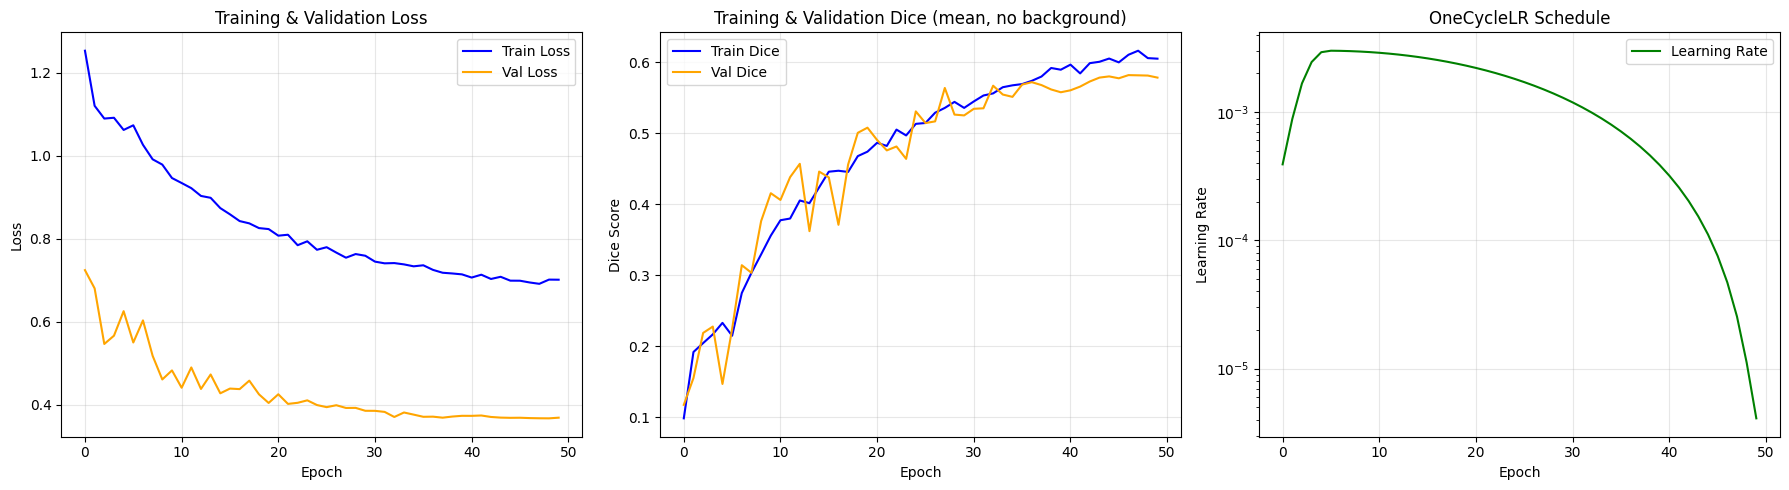

In [30]:
# Plot training history con LR curve
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
axes[0].plot(history['val_loss'], label='Val Loss', color='orange')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Dice
axes[1].plot(history['train_dice'], label='Train Dice', color='blue')
axes[1].plot(history['val_dice'], label='Val Dice', color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice Score')
axes[1].set_title('Training & Validation Dice (mean, no background)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning Rate (OneCycleLR)
axes[2].plot(history['lr'], label='Learning Rate', color='green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('OneCycleLR Schedule')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_yscale('log')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves_v2.png', dpi=150)
plt.show()

In [31]:
# Load best model and compare Standard vs TTA predictions
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
model.eval()

print("=" * 70)
print("STANDARD VS TTA PREDICTION COMPARISON")
print("=" * 70)

results_standard = {c: {'dice': [], 'iou': []} for c in range(NUM_CLASSES)}
results_tta = {c: {'dice': [], 'iou': []} for c in range(NUM_CLASSES)}

with torch.no_grad():
    for imgs, masks, _ in tqdm(test_loader, desc='Test'):
        imgs = imgs.to(device)
        masks = masks.to(device)
        
        # Standard prediction
        out_standard = model(imgs)
        metrics_std = compute_metrics_multiclass(out_standard, masks, NUM_CLASSES)
        
        # TTA prediction
        out_tta = tta_predict(model, imgs, device, NUM_CLASSES)
        metrics_tta = compute_metrics_multiclass(out_tta, masks, NUM_CLASSES)
        
        for c in range(NUM_CLASSES):
            results_standard[c]['dice'].append(metrics_std['dice_per_class'][c])
            results_standard[c]['iou'].append(metrics_std['iou_per_class'][c])
            results_tta[c]['dice'].append(metrics_tta['dice_per_class'][c])
            results_tta[c]['iou'].append(metrics_tta['iou_per_class'][c])

print(f"\n{'Class':<15} {'Standard Dice':>15} {'TTA Dice':>15} {'Delta':>8}")
print("-" * 55)

total_std_dice = []
total_tta_dice = []

for c in range(NUM_CLASSES):
    dice_std = np.mean(results_standard[c]['dice']) * 100
    dice_tta = np.mean(results_tta[c]['dice']) * 100
    delta = dice_tta - dice_std
    
    print(f'{CLASS_NAMES[c]:<15} {dice_std:>14.2f}% {dice_tta:>14.2f}% {delta:>+7.2f}%')
    
    if c > 0:
        total_std_dice.append(np.mean(results_standard[c]['dice']))
        total_tta_dice.append(np.mean(results_tta[c]['dice']))

print("-" * 55)
mean_std = np.mean(total_std_dice) * 100
mean_tta = np.mean(total_tta_dice) * 100
print(f'{"MEAN (no BG)":<15} {mean_std:>14.2f}% {mean_tta:>14.2f}% {mean_tta-mean_std:>+7.2f}%')
print("=" * 70)

all_dice = results_tta
all_iou = {c: {'iou': results_tta[c]['iou']} for c in range(NUM_CLASSES)}

STANDARD VS TTA PREDICTION COMPARISON


Test: 100%|██████████| 11/11 [00:14<00:00,  1.36s/it]


Class             Standard Dice        TTA Dice    Delta
-------------------------------------------------------
Background               98.35%          98.44%   +0.09%
Capsule                  55.84%          58.05%   +2.21%
CEC                      77.24%          77.26%   +0.01%
Medulla                  58.65%          57.86%   -0.79%
Cortex                   49.52%          51.07%   +1.55%
-------------------------------------------------------
MEAN (no BG)             60.31%          61.06%   +0.75%


# 10. Visualizzazione Predizioni Multiclasse

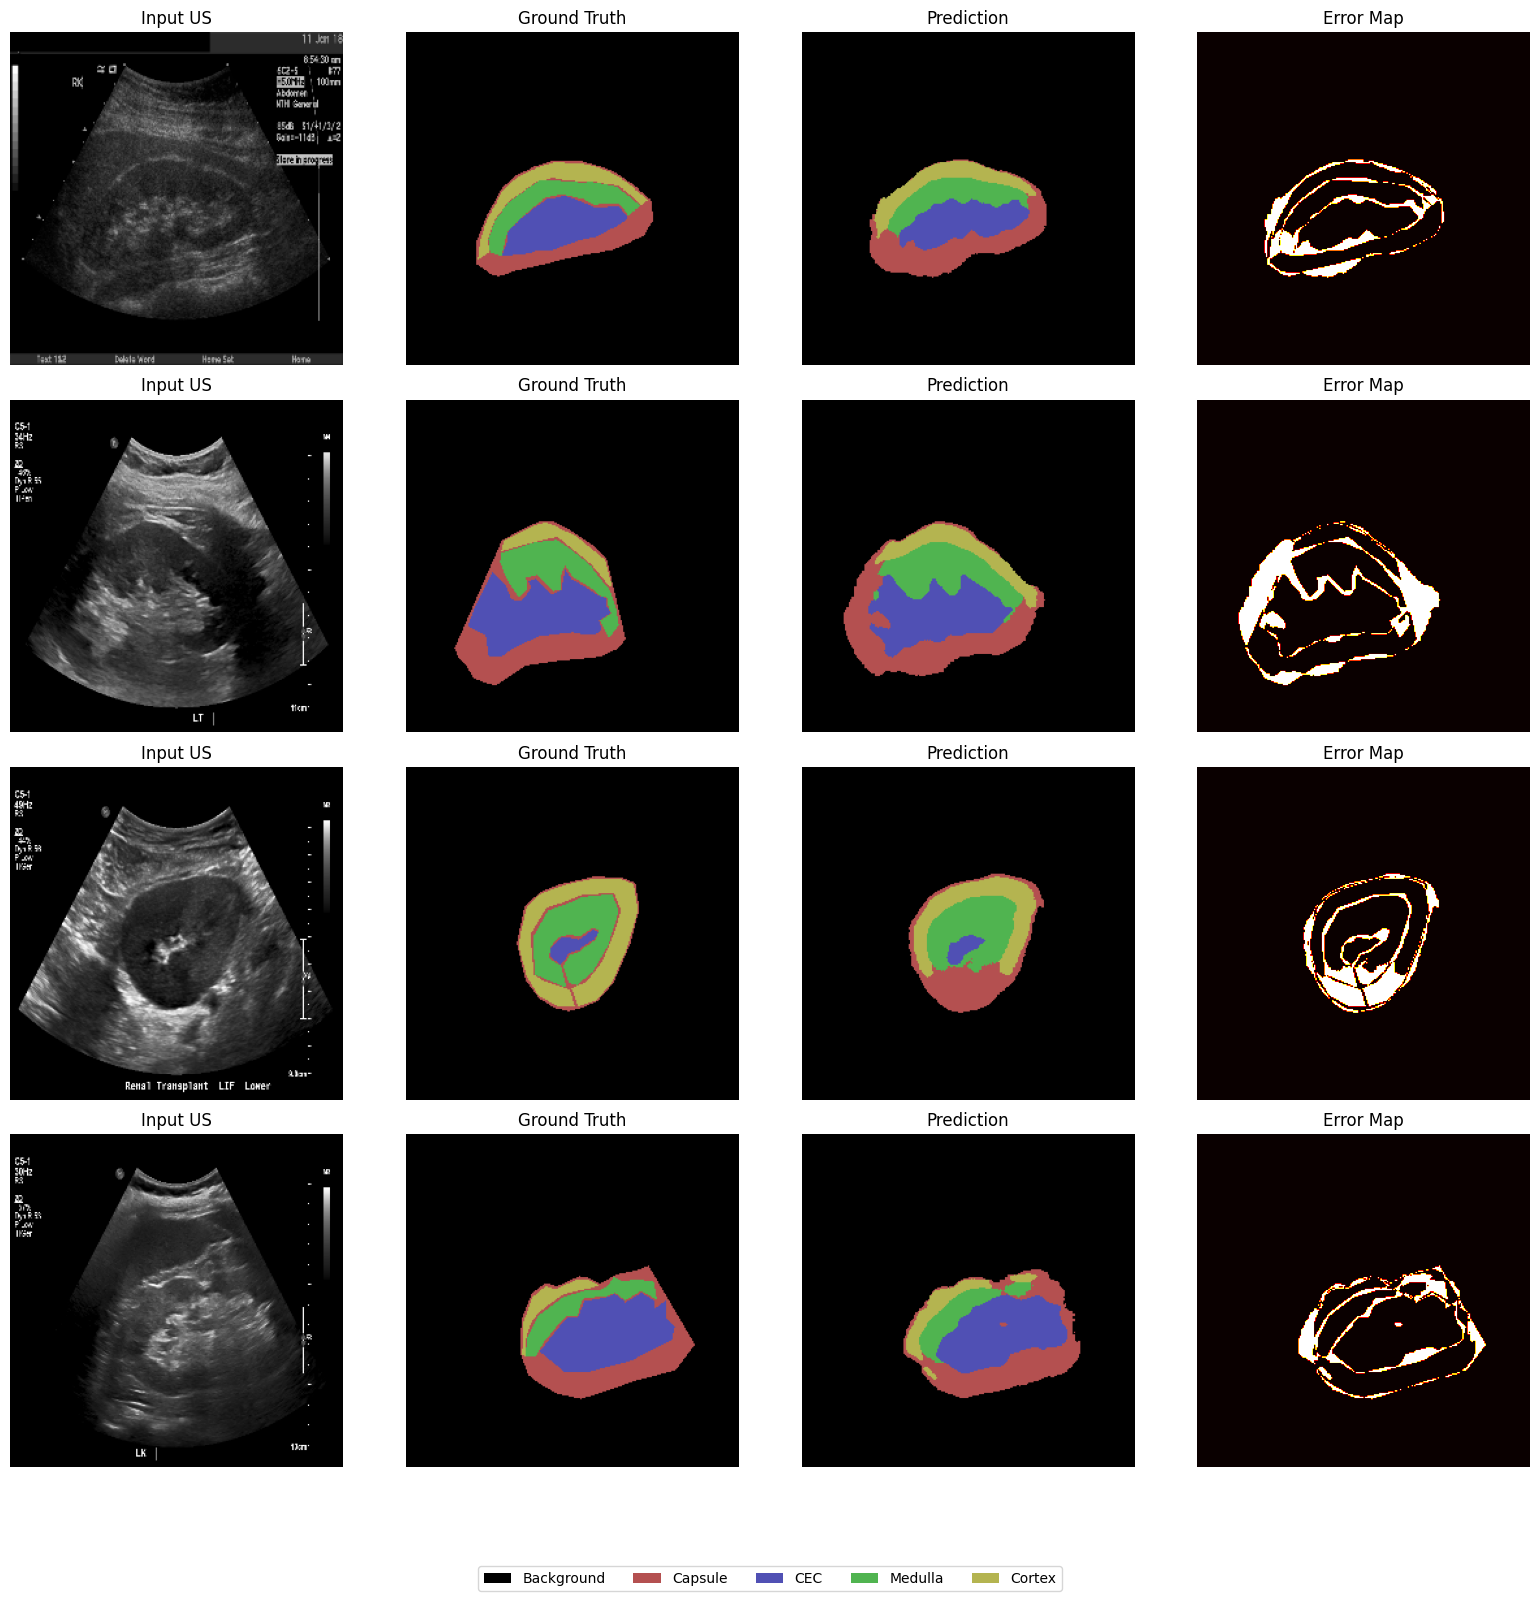

In [32]:
def visualize_predictions_multiclass(model, loader, device, n=4):
    """Visualize multiclass predictions vs ground truth."""
    model.eval()
    imgs_batch, masks_batch, names_batch = next(iter(loader))
    imgs_batch = imgs_batch.to(device)

    with torch.no_grad():
        preds = model(imgs_batch).argmax(dim=1)

    fig, axes = plt.subplots(n, 4, figsize=(16, 4*n))
    
    for i in range(min(n, len(imgs_batch))):
        img = imgs_batch[i, 0].cpu().numpy()
        gt = masks_batch[i].numpy()
        pred = preds[i].cpu().numpy()
        
        gt_rgb = np.zeros((*gt.shape, 3), dtype=np.uint8)
        pred_rgb = np.zeros((*pred.shape, 3), dtype=np.uint8)
        for c, color in enumerate(CLASS_COLORS):
            gt_rgb[gt == c] = color
            pred_rgb[pred == c] = color
        
        error = (gt != pred).astype(float)

        axes[i, 0].imshow(img, cmap='gray')
        axes[i, 0].set_title('Input US')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(gt_rgb)
        axes[i, 1].set_title('Ground Truth')
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(pred_rgb)
        axes[i, 2].set_title('Prediction')
        axes[i, 2].axis('off')
        
        axes[i, 3].imshow(error, cmap='hot')
        axes[i, 3].set_title('Error Map')
        axes[i, 3].axis('off')

    patches = [plt.Rectangle((0,0), 1, 1, fc=tuple(c/255 for c in color)) 
               for color in CLASS_COLORS]
    fig.legend(patches, CLASS_NAMES, loc='lower center', ncol=5)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)
    plt.savefig(OUTPUT_DIR / 'test_predictions_multiclass.png', dpi=150)
    plt.show()

visualize_predictions_multiclass(model, test_loader, device, n=4)

# 11. Confusion Matrix per Classe

Confusion matrix: 100%|██████████| 11/11 [00:02<00:00,  4.04it/s]


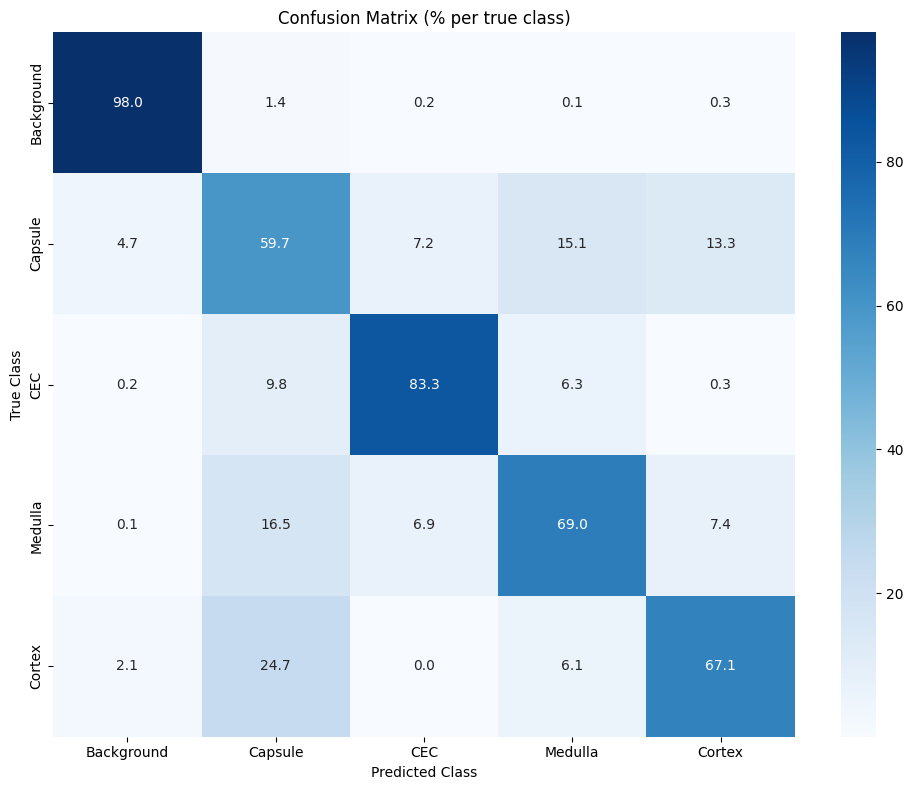

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds = []
all_targets = []

model.eval()
with torch.no_grad():
    for imgs, masks, _ in tqdm(test_loader, desc='Confusion matrix'):
        imgs = imgs.to(device)
        preds = model(imgs).argmax(dim=1).cpu().numpy().flatten()
        targets = masks.numpy().flatten()
        all_preds.extend(preds)
        all_targets.extend(targets)

cm = confusion_matrix(all_targets, all_preds, labels=range(NUM_CLASSES))
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted Class')
ax.set_ylabel('True Class')
ax.set_title('Confusion Matrix (% per true class)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

# 12. Hyperparameter Search

Testiamo diverse configurazioni di iperparametri per migliorare le performance:

In [ ]:
# Configurazioni da testare
SWEEP_CONFIGS = [
    {
        'name': 'Config 1: Baseline',
        'class_weights': [0.1, 2.5, 4.0, 7.0, 12.0],
        'focal_gamma': 2.0,
        'lovasz_weight': 0.35,
        'lr': 1e-3,
        'n_epochs': 30,
    },
    {
        'name': 'Config 2: Pesi Cortex/Medulla',
        'class_weights': [0.1, 3.0, 3.5, 9.0, 16.0],
        'focal_gamma': 2.5,
        'lovasz_weight': 0.40,
        'lr': 1e-3,
        'n_epochs': 30,
    },
    {
        'name': 'Config 3: Lovasz dominante',
        'class_weights': [0.1, 3.0, 4.0, 8.0, 14.0],
        'focal_gamma': 2.0,
        'lovasz_weight': 0.50,
        'lr': 1e-3,
        'n_epochs': 30,
    },
]

def train_with_config(config, train_loader, val_loader, device, patience=10):
    """Allena un modello con una specifica configurazione."""
    
    model = ResUNetAttention(in_channels=1, num_classes=NUM_CLASSES, base_features=64).to(device)
    class_weights = torch.tensor(config['class_weights']).to(device)
    
    optimizer = optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=1e-3)
    
    total_steps = config['n_epochs'] * len(train_loader)
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=config['lr'] * 3, total_steps=total_steps,
        pct_start=0.1, anneal_strategy='cos', div_factor=10, final_div_factor=100
    )
    
    best_val_dice = 0.0
    epochs_no_improve = 0
    
    for epoch in range(config['n_epochs']):
        model.train()
        for imgs, masks, _ in train_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()
            
            outputs = model(imgs, return_aux=True)
            
            loss, _ = deep_supervision_loss_v3(
                outputs, masks, class_weights=class_weights, 
                num_classes=NUM_CLASSES, focal_gamma=config['focal_gamma'],
                ds_weights=[1.0, 0.4, 0.3, 0.2]
            )
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
        
        model.eval()
        val_dice_scores = []
        with torch.no_grad():
            for imgs, masks, _ in val_loader:
                imgs, masks = imgs.to(device), masks.to(device)
                out = model(imgs, return_aux=False)
                metrics = compute_metrics_multiclass(out, masks, NUM_CLASSES)
                val_dice_scores.append(metrics['mean_dice'])
        
        val_dice = np.mean(val_dice_scores)
        
        if val_dice > best_val_dice:
            best_val_dice = val_dice
            best_model_state = model.state_dict().copy()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break
    
    model.load_state_dict(best_model_state)
    model.eval()
    
    test_dice = {c: [] for c in range(NUM_CLASSES)}
    with torch.no_grad():
        for imgs, masks, _ in test_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            out_tta = tta_predict(model, imgs, device, NUM_CLASSES)
            metrics = compute_metrics_multiclass(out_tta, masks, NUM_CLASSES)
            for c in range(NUM_CLASSES):
                test_dice[c].append(metrics['dice_per_class'][c])
    
    results = {
        'val_dice': best_val_dice * 100,
        'test_dice': {CLASS_NAMES[c]: np.mean(test_dice[c]) * 100 for c in range(NUM_CLASSES)},
        'test_mean': np.mean([np.mean(test_dice[c]) for c in range(1, NUM_CLASSES)]) * 100,
        'model_state': best_model_state
    }
    
    return results


print("=" * 80)
print("HYPERPARAMETER SWEEP")
print("=" * 80)
print(f"\nConfigurations: {len(SWEEP_CONFIGS)}")
print(f"Epochs per config: 30 (early stopping, patience=10)")
print(f"Evaluation: TTA on test set\n")

sweep_results = []

for i, config in enumerate(SWEEP_CONFIGS):
    print(f"\n{'='*60}")
    print(f"[{i+1}/{len(SWEEP_CONFIGS)}] {config['name']}")
    print(f"{'='*60}")
    print(f"  class_weights: {config['class_weights']}")
    print(f"  focal_gamma: {config['focal_gamma']}")
    print(f"  lovasz_weight: {config['lovasz_weight']}")
    print(f"  lr: {config['lr']}")
    print()
    
    results = train_with_config(config, train_loader, val_loader, device, patience=10)
    results['config'] = config
    sweep_results.append(results)
    
    print(f"  Val Dice: {results['val_dice']:.2f}%")
    print(f"  Test Dice (TTA): {results['test_mean']:.2f}%")
    print(f"    Capsule: {results['test_dice']['Capsule']:.2f}%")
    print(f"    CEC: {results['test_dice']['CEC']:.2f}%")
    print(f"    Medulla: {results['test_dice']['Medulla']:.2f}%")
    print(f"    Cortex: {results['test_dice']['Cortex']:.2f}%")

print("\n" + "=" * 80)

🔬 HYPERPARAMETER SWEEP

Testando 3 configurazioni...
Epoche per config: 30 (con early stopping, patience=10)
Valutazione: TTA sul test set


[1/3] Config 1: Baseline
  class_weights: [0.1, 2.5, 4.0, 7.0, 12.0]
  focal_gamma: 2.0
  lovasz_weight: 0.35
  lr: 0.001

  ✓ Val Dice: 55.89%
  ✓ Test Dice (TTA): 58.52%
    - Capsule: 53.82%
    - CEC: 76.02%
    - Medulla: 56.28%
    - Cortex: 47.97%

[2/3] Config 2: Pesi Cortex/Medulla
  class_weights: [0.1, 3.0, 3.5, 9.0, 16.0]
  focal_gamma: 2.5
  lovasz_weight: 0.4
  lr: 0.001

  ✓ Val Dice: 53.63%
  ✓ Test Dice (TTA): 55.73%
    - Capsule: 46.36%
    - CEC: 75.21%
    - Medulla: 54.74%
    - Cortex: 46.61%

[3/3] Config 3: Lovász dominante
  class_weights: [0.1, 3.0, 4.0, 8.0, 14.0]
  focal_gamma: 2.0
  lovasz_weight: 0.5
  lr: 0.001

  ✓ Val Dice: 54.90%
  ✓ Test Dice (TTA): 57.18%
    - Capsule: 48.66%
    - CEC: 74.63%
    - Medulla: 56.51%
    - Cortex: 48.92%



 RIEPILOGO HYPERPARAMETER SWEEP

Rank  Config                                Val Dice  Test Dice
-----------------------------------------------------------------
🏆1   Config 1: Baseline                      55.89%     58.52%
  2   Config 3: Lovász dominante              54.90%     57.18%
  3   Config 2: Pesi Cortex/Medulla           53.63%     55.73%
-----------------------------------------------------------------

 BEST CONFIGURATION: Config 1: Baseline

   Parametri:
   - class_weights: [0.1, 2.5, 4.0, 7.0, 12.0]
   - focal_gamma: 2.0
   - lovasz_weight: 0.35
   - lr: 0.001

   Risultati per classe:
   - Capsule: 53.82%
   - CEC: 76.02%
   - Medulla: 56.28%
   - Cortex: 47.97%

    TEST MEAN DICE: 58.52%

    Best model salvato: /Users/ada/Desktop/SegRENE/outputs/best_sweep_model.pth


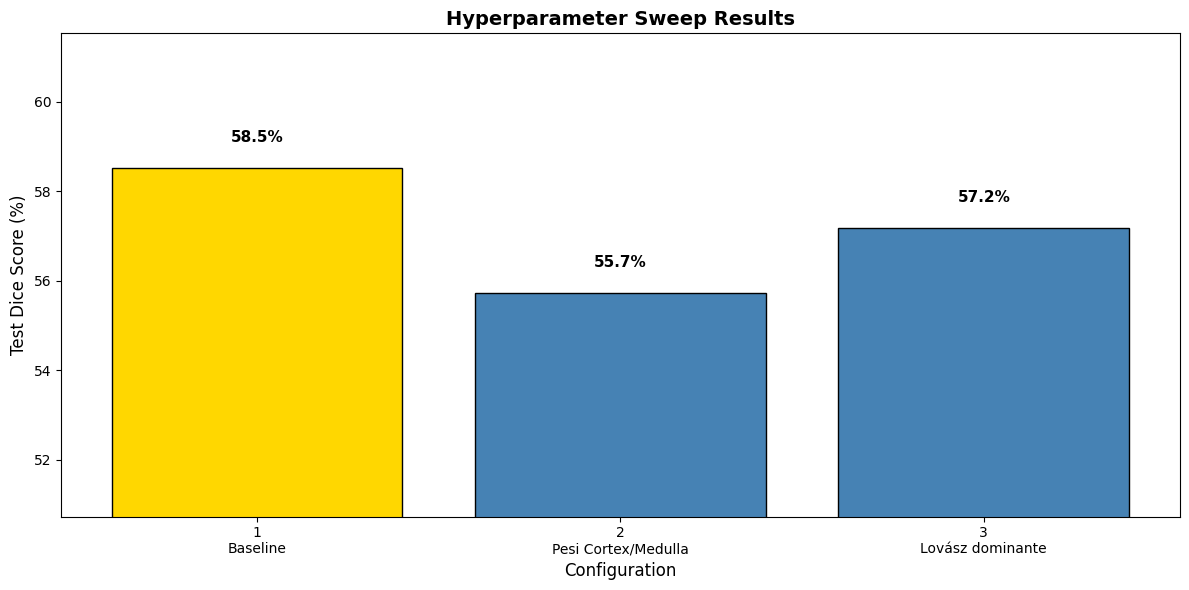

In [ ]:
# Riepilogo sweep e selezione best config

print("=" * 80)
print("HYPERPARAMETER SWEEP SUMMARY")
print("=" * 80)

sweep_results_sorted = sorted(sweep_results, key=lambda x: x['test_mean'], reverse=True)

print(f"\n{'Rank':<5} {'Config':<35} {'Val Dice':>10} {'Test Dice':>10}")
print("-" * 65)

for rank, res in enumerate(sweep_results_sorted, 1):
    marker = "*" if rank == 1 else " "
    print(f"{marker}{rank:<4} {res['config']['name']:<35} {res['val_dice']:>9.2f}% {res['test_mean']:>9.2f}%")

print("-" * 65)

best_result = sweep_results_sorted[0]
print(f"\nBEST CONFIGURATION: {best_result['config']['name']}")
print(f"\nParameters:")
print(f"  class_weights: {best_result['config']['class_weights']}")
print(f"  focal_gamma: {best_result['config']['focal_gamma']}")
print(f"  lovasz_weight: {best_result['config']['lovasz_weight']}")
print(f"  lr: {best_result['config']['lr']}")
print(f"\nResults per class:")
for cls_name in ['Capsule', 'CEC', 'Medulla', 'Cortex']:
    print(f"  {cls_name}: {best_result['test_dice'][cls_name]:.2f}%")
print(f"\nTEST MEAN DICE: {best_result['test_mean']:.2f}%")

BEST_SWEEP_PATH = OUTPUT_DIR / 'best_sweep_model.pth'
torch.save(best_result['model_state'], BEST_SWEEP_PATH)
print(f"\nBest model saved: {BEST_SWEEP_PATH}")

fig, ax = plt.subplots(figsize=(12, 6))

configs = [r['config']['name'].replace('Config ', '').replace(': ', '\n') for r in sweep_results]
test_dices = [r['test_mean'] for r in sweep_results]
colors = ['gold' if d == max(test_dices) else 'steelblue' for d in test_dices]

bars = ax.bar(configs, test_dices, color=colors, edgecolor='black')
ax.set_ylabel('Test Dice Score (%)', fontsize=12)
ax.set_xlabel('Configuration', fontsize=12)
ax.set_title('Hyperparameter Sweep Results', fontsize=14, fontweight='bold')
ax.set_ylim(min(test_dices) - 5, max(test_dices) + 3)

for bar, val in zip(bars, test_dices):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'hyperparameter_sweep_results.png', dpi=150)
plt.show()

print("=" * 80)